# Exploratory Data Analysis (EDA) and Data Cleaning (2021 - 2022)
Goal: Clean NBA shot data, define clutch scenarios, and prepare for ML modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
clutch_df = pd.read_csv("../data/raw/shot_data.2021.csv")

In [ ]:
# Basic Dataset Information
print("Dataset Shape:", clutch_df.shape)
print("Number of Features:", clutch_df.shape[1])
print("Number of Instances:", clutch_df.shape[0])

Dataset Shape: (1343, 26)
Number of Features: 26
Number of Instances: 1343


In [ ]:
# Summary of Data Types
clutch_df.info()

<class 'pandas.DataFrame'>
Index: 1343 entries, 21 to 29293
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   GRID_TYPE            1343 non-null   str  
 1   GAME_ID              1343 non-null   int64
 2   GAME_EVENT_ID        1343 non-null   int64
 3   PLAYER_ID            1343 non-null   int64
 4   PLAYER_NAME          1343 non-null   str  
 5   TEAM_ID              1343 non-null   int64
 6   TEAM_NAME            1343 non-null   str  
 7   PERIOD               1343 non-null   int64
 8   MINUTES_REMAINING    1343 non-null   int64
 9   SECONDS_REMAINING    1343 non-null   int64
 10  EVENT_TYPE           1343 non-null   str  
 11  ACTION_TYPE          1343 non-null   str  
 12  SHOT_TYPE            1343 non-null   str  
 13  SHOT_ZONE_BASIC      1343 non-null   str  
 14  SHOT_ZONE_AREA       1343 non-null   str  
 15  SHOT_ZONE_RANGE      1343 non-null   str  
 16  SHOT_DISTANCE        1343 non-null   i

In [ ]:
# Missing Values Analysis: means to identify any columns with missing data and understand the extent of "missingness"
missing_values = clutch_df.isnull().sum()
missing_percent = (missing_values / len(clutch_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_percent
})

print(missing_df[missing_df['Missing Count'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [ ]:
# Drop rows with missing values in critical columns
df = clutch_df.dropna(subset=[
    'SHOT_DISTANCE',
    'SHOT_MADE_FLAG',
    'PERIOD',
    'MINUTES_REMAINING',
    'SECONDS_REMAINING'
])

In [ ]:
# Print the shape of the cleaned dataset, clean shape ensures removal of missing values
print("Cleaned Shape:", df.shape)

Cleaned Shape: (29310, 24)


In [ ]:
# Time Remaining Calculation: Create a new column, combines minutes and seconds remaining into a single value representing total seconds remaining in the period
df['TIME_REMAINING'] = (
    df['MINUTES_REMAINING'] * 60 +
    df['SECONDS_REMAINING']
)

In [ ]:
# Define clutch situations: 4th quarter or overtime with 2 minutes or less remaining
df['CLUTCH'] = (
    (df['PERIOD'] >= 4) &
    (df['TIME_REMAINING'] <= 120)
)

In [ ]:
# Filter the dataset to include only clutch situations
clutch_df = df[df['CLUTCH'] == True]

In [11]:
print("Clutch Dataset Shape:", clutch_df.shape)
print(clutch_df['PLAYER_NAME'].value_counts())

Clutch Dataset Shape: (1343, 26)
PLAYER_NAME
LeBron James               79
Donovan Mitchell           75
Joel Embiid                71
Trae Young                 70
Nikola Jokić               68
Devin Booker               68
Ja Morant                  67
Luka Dončić                62
Shai Gilgeous-Alexander    62
Stephen Curry              60
De'Aaron Fox               57
Jaylen Brown               55
Jordan Poole               55
Jayson Tatum               54
Giannis Antetokounmpo      53
Anthony Edwards            53
Brandon Ingram             52
Kevin Durant               49
Pascal Siakam              48
Karl-Anthony Towns         34
Aaron Gordon               29
Bam Adebayo                27
Klay Thompson              24
Anthony Davis              21
Damian Lillard             21
Rudy Gobert                19
Otto Porter Jr.            10
Name: count, dtype: int64


In [ ]:
# Save the processed clutch dataset to a new CSV file
clutch_df.to_csv("../data/processed/clutch_shot_data.2021.csv", index=False)

In [ ]:
# Analyze shooting performance by player in clutch situations
player_fg = clutch_df.groupby('PLAYER_NAME')['SHOT_MADE_FLAG'].mean().sort_values(ascending=False)

print(player_fg)

PLAYER_NAME
Rudy Gobert                0.842105
Giannis Antetokounmpo      0.641509
Bam Adebayo                0.592593
Karl-Anthony Towns         0.588235
Anthony Davis              0.571429
Aaron Gordon               0.551724
Nikola Jokić               0.544118
Devin Booker               0.529412
Jordan Poole               0.509091
De'Aaron Fox               0.491228
Trae Young                 0.471429
Kevin Durant               0.469388
Shai Gilgeous-Alexander    0.467742
Pascal Siakam              0.458333
Joel Embiid                0.408451
Brandon Ingram             0.403846
Stephen Curry              0.400000
Donovan Mitchell           0.373333
Ja Morant                  0.373134
Luka Dončić                0.370968
Jaylen Brown               0.363636
Anthony Edwards            0.358491
LeBron James               0.354430
Jayson Tatum               0.351852
Otto Porter Jr.            0.300000
Klay Thompson              0.291667
Damian Lillard             0.285714
Name: SHOT_MADE_

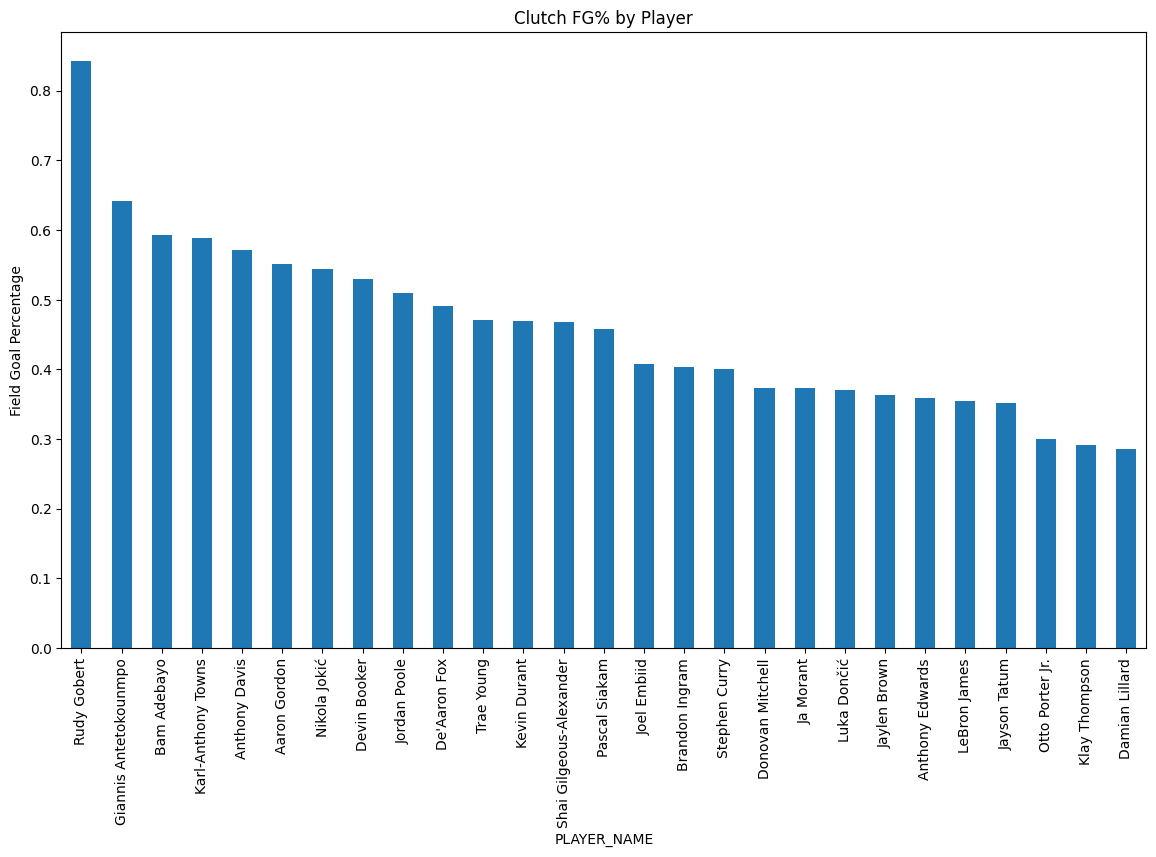

In [14]:
plt.figure(figsize=(14,8))
player_fg.plot(kind='bar')
plt.title("Clutch FG% by Player")
plt.ylabel("Field Goal Percentage")
plt.show()

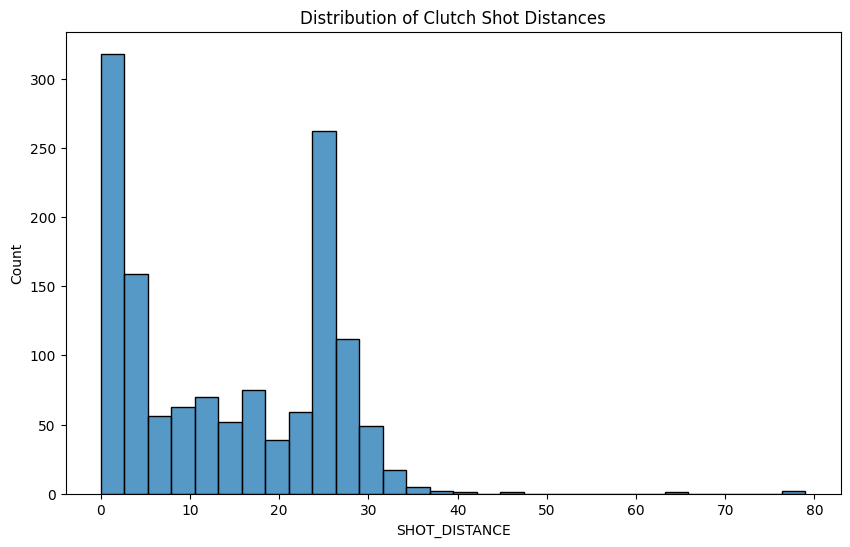

In [ ]:
# Histogram of shot distances in clutch situations to understand the distribution of shot distances taken during clutch moments
plt.figure(figsize=(10,6))
sns.histplot(clutch_df['SHOT_DISTANCE'], bins=30)
plt.title("Distribution of Clutch Shot Distances")
plt.show()

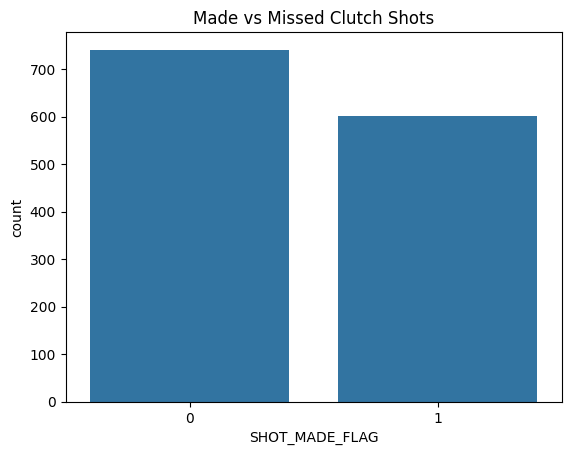

In [20]:
sns.countplot(x='SHOT_MADE_FLAG', data=clutch_df)
plt.title("Made vs Missed Clutch Shots")
plt.show()

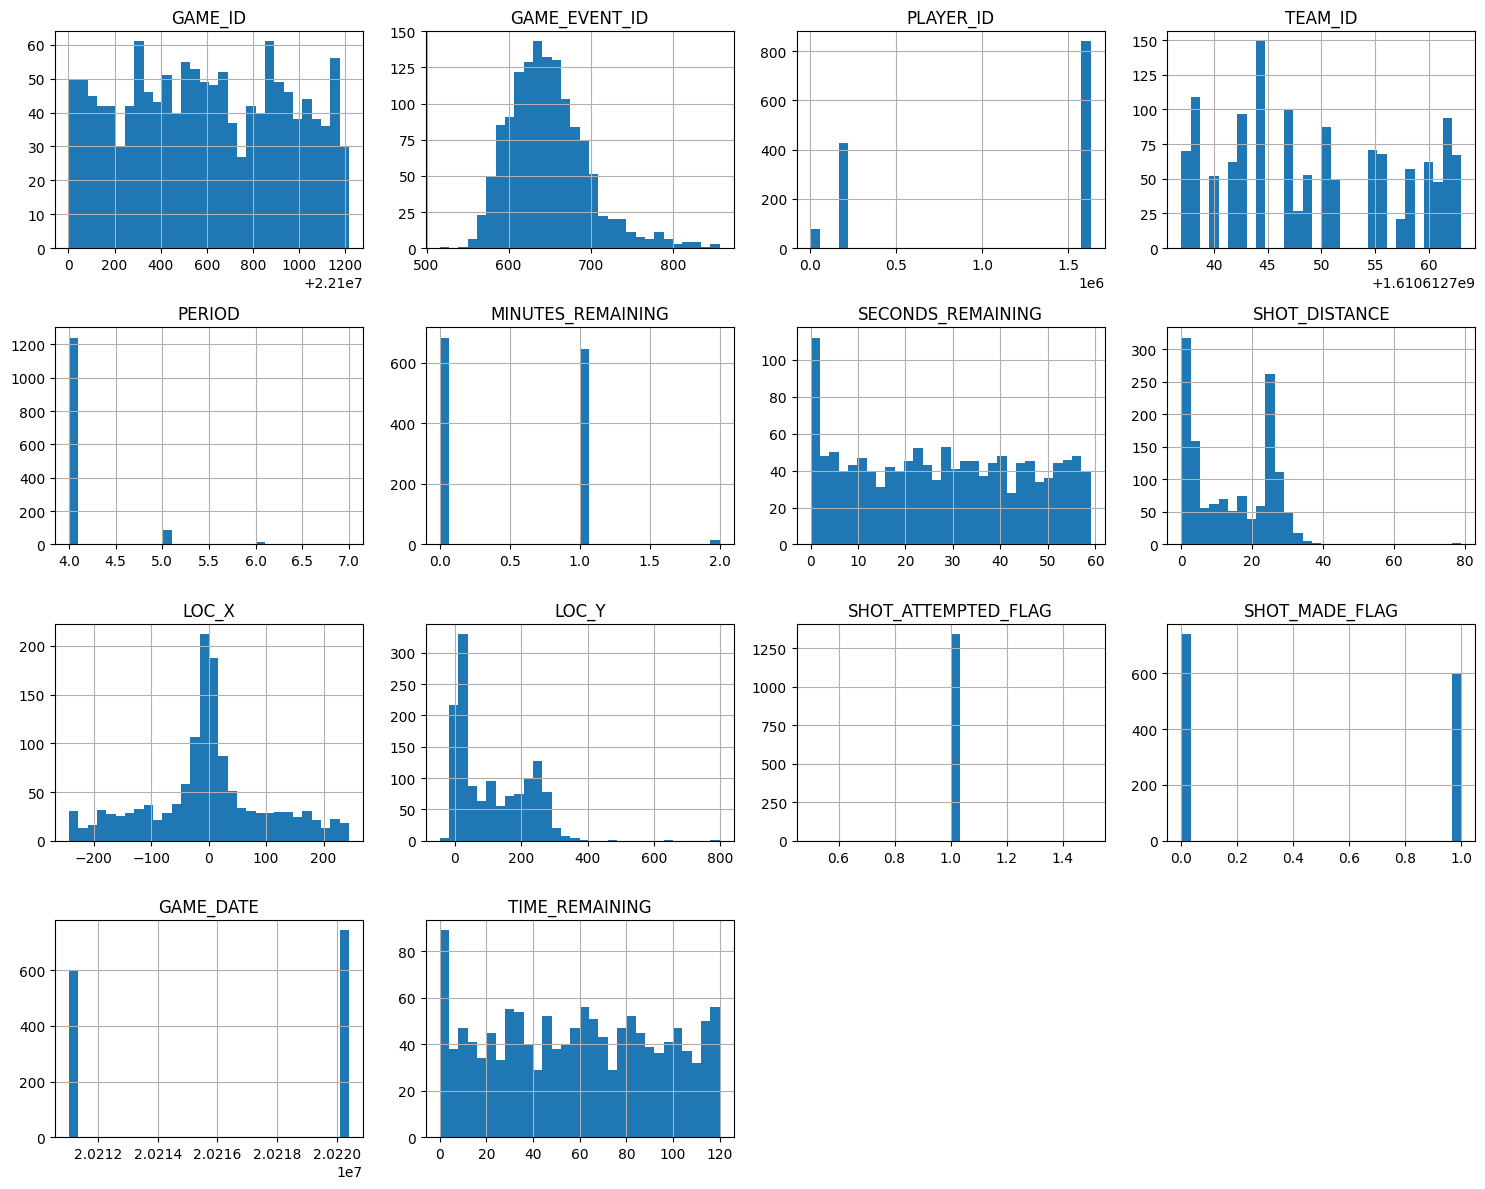

In [ ]:
# Graphs for each numeric column to find any odd distributions or outliers that may need to be addressed in the modeling phase
numeric_cols = clutch_df.select_dtypes(include=['int64', 'float64']).columns

clutch_df[numeric_cols].hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

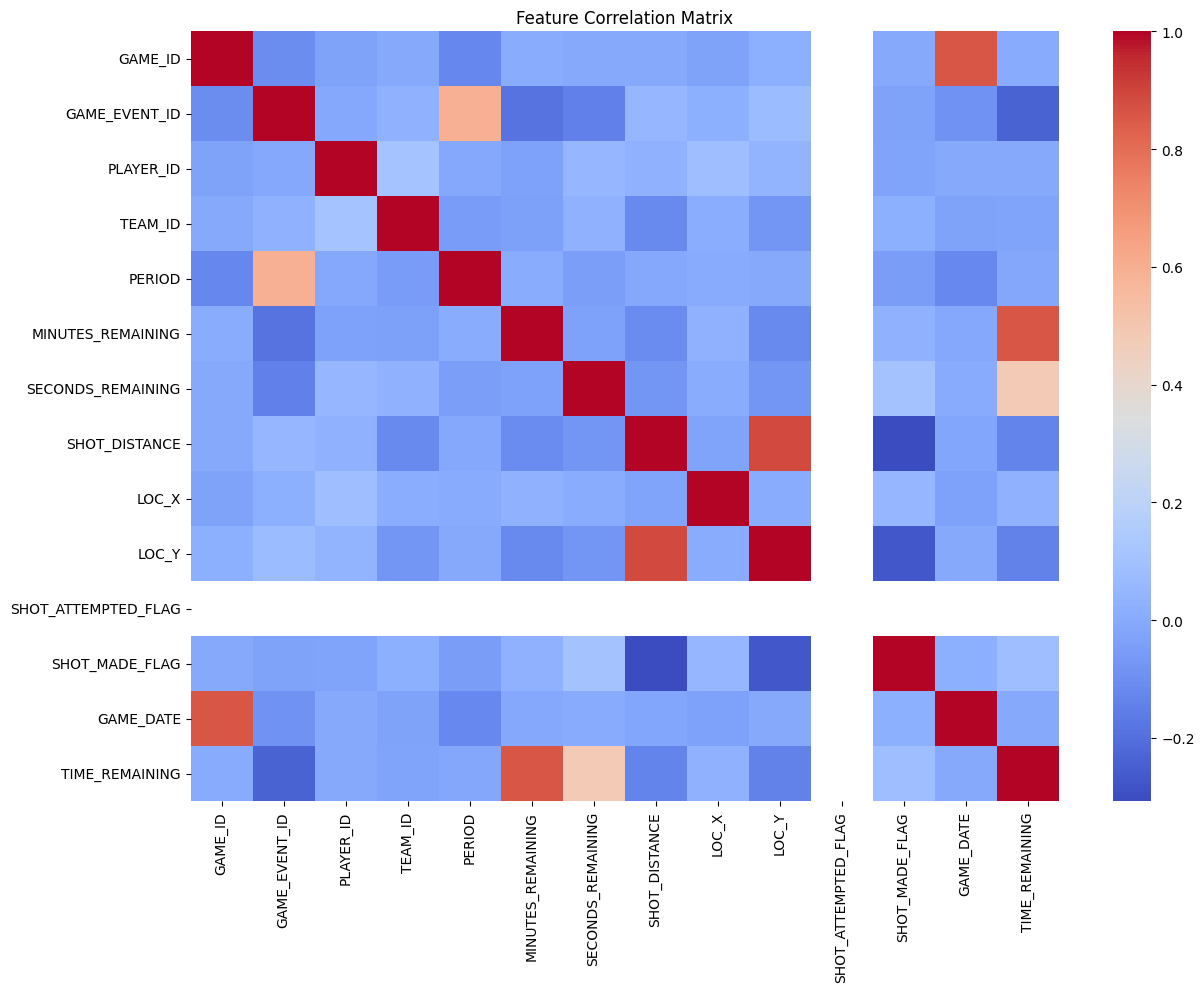

In [ ]:
# Correlation Matrix to calculate the correlation between numeric features in the clutch dataset, to identify which features are strongly correlated with each other and with the target variable (SHOT_MADE_FLAG), in order to inform feature selection and engineering for modeling
corr_matrix = clutch_df[numeric_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# Calculate and print the variance of each numeric feature to identify which features have low variance and may not contribute much to the model
# Low variance = may not be useful for prediction and could potentially be removed to simplify the model
# High variance = may contain more information and be more useful for prediction
feature_variance = clutch_df[numeric_cols].var()
print(feature_variance.sort_values())

SHOT_ATTEMPTED_FLAG    0.000000e+00
PERIOD                 1.253195e-01
SHOT_MADE_FLAG         2.475063e-01
MINUTES_REMAINING      2.725297e-01
TEAM_ID                6.957635e+01
SHOT_DISTANCE          1.263385e+02
SECONDS_REMAINING      3.285099e+02
TIME_REMAINING         1.273194e+03
GAME_EVENT_ID          2.342000e+03
LOC_X                  1.062009e+04
LOC_Y                  1.114888e+04
GAME_ID                1.199784e+05
GAME_DATE              2.044022e+07
PLAYER_ID              4.999018e+11
dtype: float64


In [ ]:
# Standardize numeric features to have mean = 0 and variance = 1
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(clutch_df[numeric_cols])

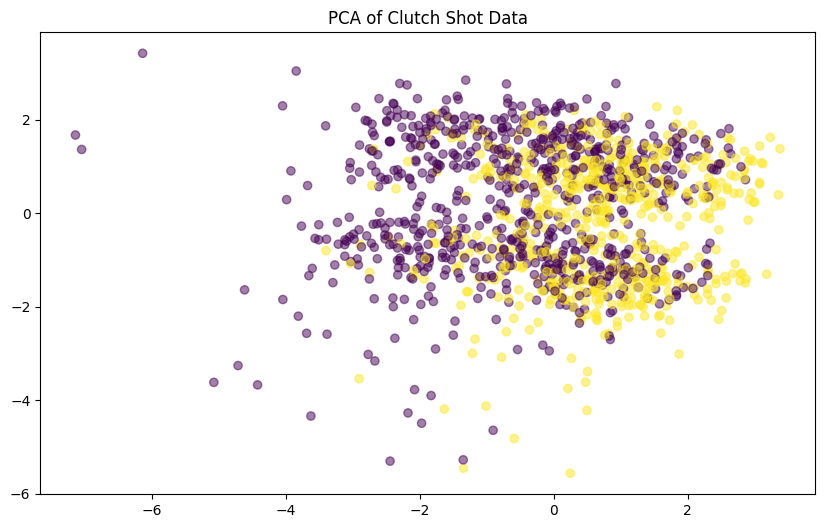

In [ ]:
# Perform PCA to reduce dimensionality and visualize the data in 2D, allowing us to see if there are any natural clusters or separations in the data based on the clutch shot features
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

plt.figure(figsize=(10,6))
plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=clutch_df['SHOT_MADE_FLAG'],
    alpha=0.5
)
plt.title("PCA of Clutch Shot Data")
plt.show()

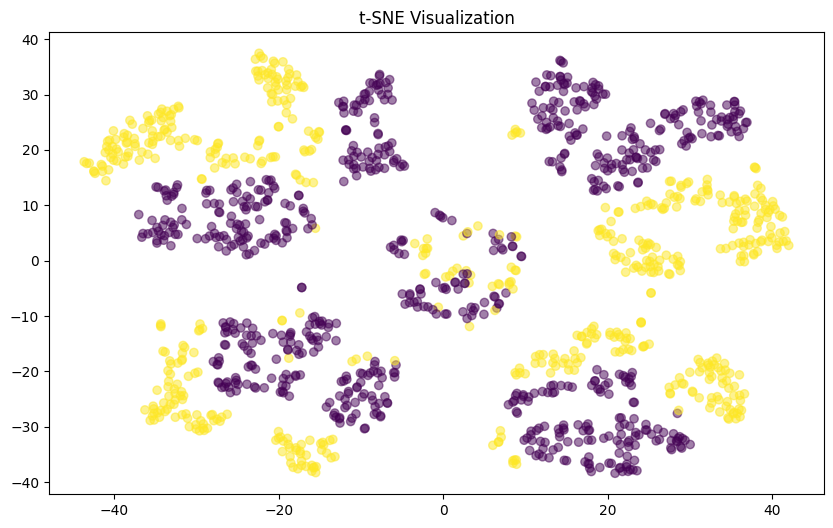

In [ ]:
# Perform t-SNE for a more complex, non-linear dimensionality reduction to visualize potential clusters in the clutch shot data, which may not be captured by PCA
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(scaled_features[:5000])  # sample for speed, 

plt.figure(figsize=(10,6))
plt.scatter(
    tsne_result[:,0],
    tsne_result[:,1],
    c=clutch_df['SHOT_MADE_FLAG'][:5000],
    alpha=0.5
)
plt.title("t-SNE Visualization")
plt.show()